# Main Fig 5 — AUROC Gain Waterfall

**Data**: `analysis.csv` with all K values (phase0_v3)  
**Tasks (main)**: 2 — BMI (context-insensitive), Sleep Efficiency (context-driven)  
**Layout**: 1 row × 2 cols, wider than single column, centered in paper  

Decomposes final AUROC into additive contributions:  
1. **Base**: MeanPool @ 30s, K=1 — minimal effort baseline  
2. **+Aggregation**: K=1→all at 30s — inference-time gain (no retraining)  
3. **+Context**: 30s→240m at MeanPool K=all — training context gain  
4. **+Architecture**: MeanPool→Transformer at 240m K=all — architecture gain  
5. **=Final**: Transformer @ 240m K=all — stacked total  

Two tasks chosen for contrasting profiles:  
- **(a) bmi_binary**: near-flat gains — context-insensitive; architecture dominates  
- **(b) sleep_efficiency_binary**: large context gain — training context is the primary driver  

Remaining tasks (sex, age, apnea, depression, OSA) → `sfig_waterfall.pdf`.

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL,
)
from utils.data import set_root, load_analysis_all_k
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")

In [4]:
METRIC = "mean_prob_auroc"
SPLIT  = "test"

# ── Main figure: 2 tasks with contrasting gain profiles ──────────────────────
# (a) bmi_binary:              near-flat gains — context-insensitive
# (b) sleep_efficiency_binary: context is primary driver of gain
TASKS = ["bmi_binary", "sleep_efficiency_binary"]

# Load analysis.csv keeping ALL K values (needed for waterfall steps)
df_allk = load_analysis_all_k("phase0_v3", split=SPLIT)

# Sanity: confirm K=1 and K=all are present
_check = df_allk[
    (df_allk["task"] == "sleep_efficiency_binary") &
    (df_allk["head"] == "mean_pool") &
    (df_allk["context_length"] == "30s")
][["k", "mean_prob_auroc"]]
print("K values available @ sleep_eff / mean_pool / 30s:")
print(_check.sort_values("k").to_string())

K values available @ sleep_eff / mean_pool / 30s:
        k  mean_prob_auroc
1483    1         0.650228
1484   10         0.689106
1485  100         0.693052
1486   12         0.690675
1487  120         0.693383
1488   16         0.691112
1489  160         0.693078
1490    2         0.650218
1491   20         0.693802
1492  200         0.693539
1493   25         0.691529
1494  250         0.693459
1495    3         0.671511
1496   30         0.693239
1497  320         0.693428
1498    4         0.679151
1499   40         0.693642
1500  400         0.693492
1501    5         0.678578
1502   50         0.693395
1503  500         0.693330
1504    6         0.681032
1505   60         0.693257
1506    8         0.684001
1507   80         0.692961
1508  all         0.693561


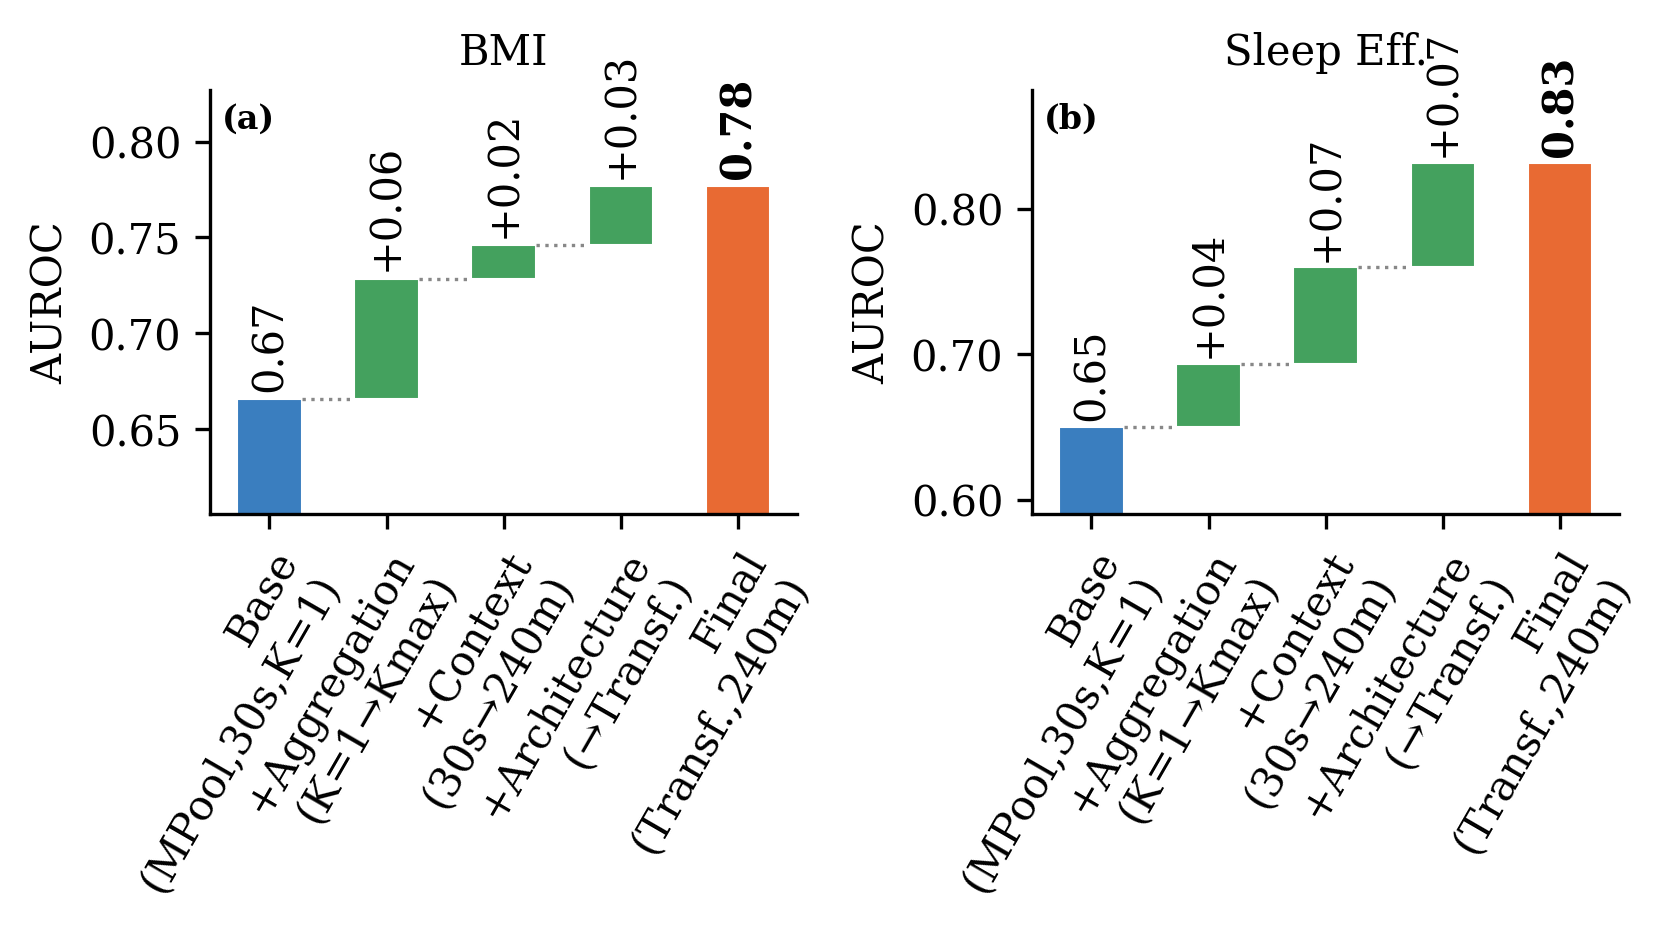

In [5]:
WATERFALL_W = FULL_W * 0.80   # ≈5.6 in
ROW_H = 3.4

fig, axes = plt.subplots(1, 2, figsize=(WATERFALL_W, ROW_H-1))

for i, (ax, task) in enumerate(zip(axes, TASKS)):
    panels.waterfall_panel(ax, df_allk, task, metric=METRIC)
    ax.set_title(TASK_LABEL[task], fontsize=FONT_BASE+2)
    add_panel_label(ax, f"({chr(97+i)})")

fig.tight_layout()
fig.subplots_adjust(bottom=0.28)
plt.show()

In [ ]:
# ── Run when figure looks good ──────────────────────────────────
save_figure(fig, FINAL_OUT, "main_fig5_waterfall")
print("Saved →", FINAL_OUT / "main_fig5_waterfall.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/main_fig7_waterfall.pdf
Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/main_fig7_waterfall.pdf


## ── SUPPLEMENTARY VERSION ─────────────────────────────────────────────────────

**Target:** `sfig_waterfall.pdf`  
**→ also copy to:** `npj_digital_medicine_submission/sfig_waterfall.pdf`  

Waterfall decomposition for remaining tasks not shown in the main figure:  
- **(a) sex_binary** — large architecture gain; aggregation also notable  
- **(b) age_class** — long context strongly beneficial (similar to sleep eff.)  
- **(c) apnea_binary** — moderate context gain; aggregation meaningful  
- **(d) depression_extreme_binary** — small overall gain; baseline already informative  
- **(e) osa_binary_apples_postqc** — near-ceiling baseline; all deltas small  

Layout: 3+2 mosaic (row 0: sex, age, apnea; row 1: depression, osa — centred).

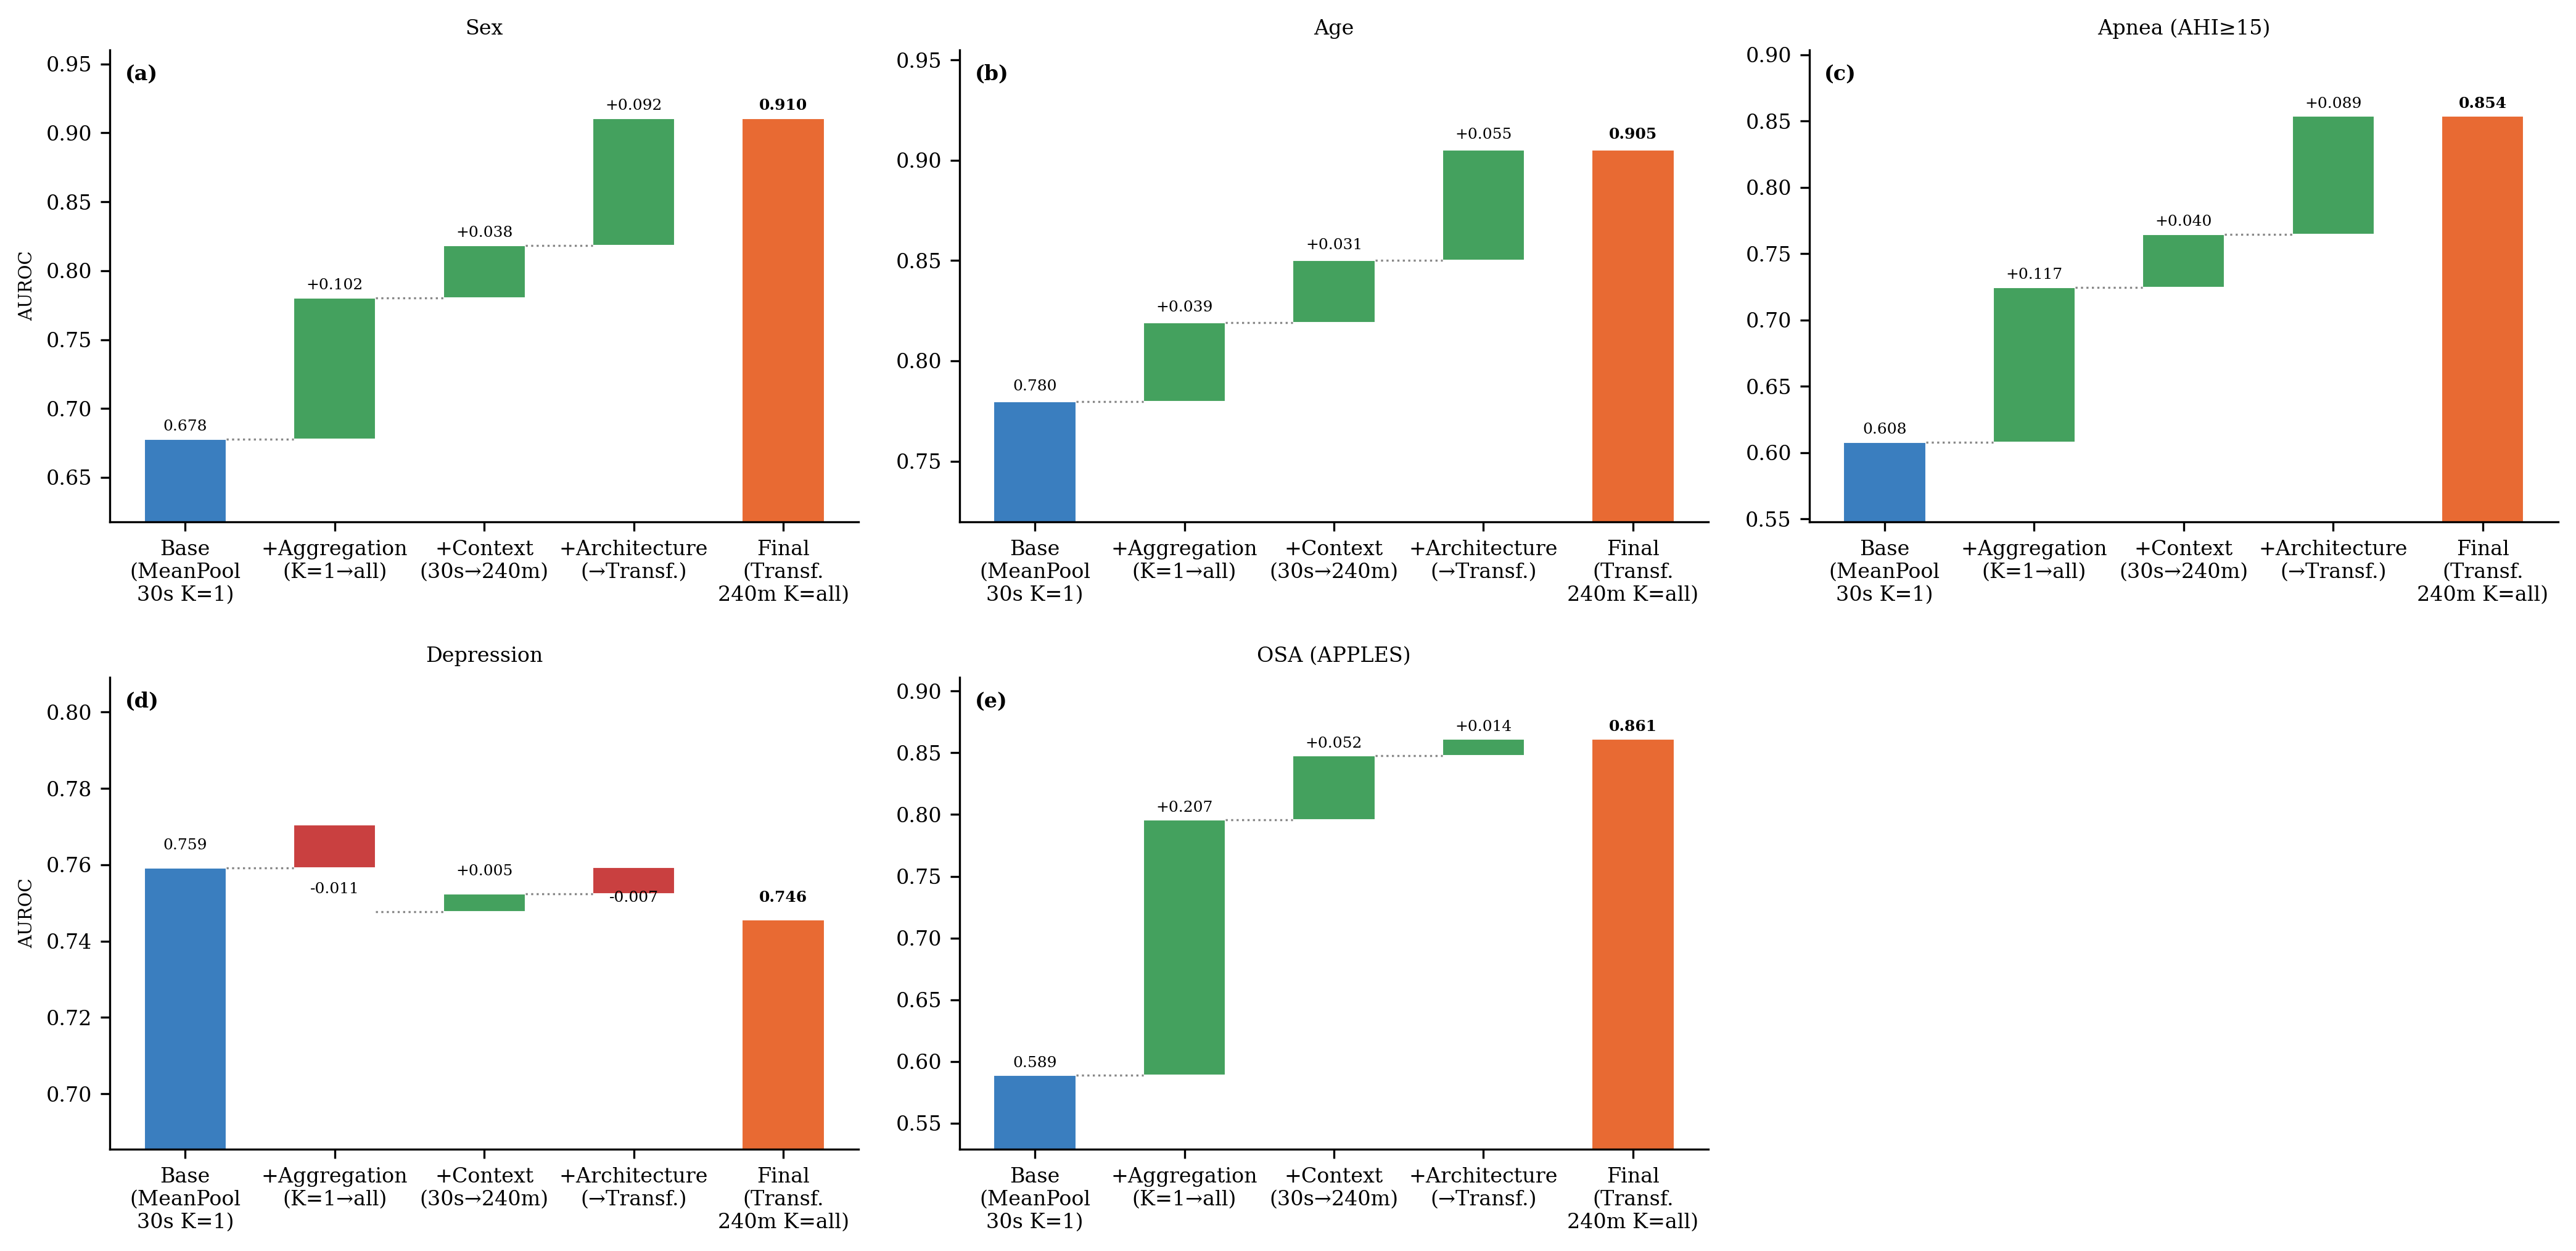

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTARY  sfig_waterfall — waterfall decomposition, remaining tasks
# Target: sfig_waterfall.pdf  (copy to npj_digital_medicine_submission/ when done)
# ══════════════════════════════════════════════════════════════════════════════

_SUPP_TASKS = [
    "sex_binary",
    "age_class",
    "apnea_binary",
    "depression_extreme_binary",
    "osa_binary_apples_postqc",
]
_N_COLS = 3
_N_ROWS = (len(_SUPP_TASKS) + _N_COLS - 1) // _N_COLS   # = 2
_labels = [chr(97 + i) for i in range(len(_SUPP_TASKS))]

# 3+2 centred mosaic — each row must be exactly _N_COLS wide
_n_full = len(_SUPP_TASKS) // _N_COLS   # = 1
_mosaic = []
for _row in range(_n_full):
    _mosaic.append(list(_labels[_row * _N_COLS:(_row + 1) * _N_COLS]))
_last_row = list(_labels[_n_full * _N_COLS:])
_pad_left  = (_N_COLS - len(_last_row)) // 2
_pad_right = _N_COLS - len(_last_row) - _pad_left
_mosaic.append(["."] * _pad_left + _last_row + ["."] * _pad_right)

fig_supp, axd = plt.subplot_mosaic(
    _mosaic,
    figsize=(FULL_W*2, _N_ROWS * ROW_H),
)

for _i, (_lbl, _task) in enumerate(zip(_labels, _SUPP_TASKS)):
    _ax = axd[_lbl]
    panels.waterfall_panel(_ax, df_allk, _task, metric=METRIC)
    _ax.set_title(TASK_LABEL[_task], fontsize=8)
    add_panel_label(_ax, f"({_lbl})")
    if _i % _N_COLS != 0:
        _ax.set_ylabel("")

fig_supp.tight_layout(h_pad=2.0, w_pad=1.5)
plt.show()

In [8]:
# Save and copy to npj_digital_medicine_submission
save_figure(fig_supp, FINAL_OUT, "sfig_waterfall")
import shutil
_submission = WORKSPACE_ROOT / "npj_digital_medicine_submission"
shutil.copy(FINAL_OUT / "sfig_waterfall.pdf",
            _submission / "sfig_waterfall.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig_waterfall.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig_waterfall.pdf
Saved + copied → TBME_submission/sfig_waterfall.pdf
